# 04 · Nube de puntos + PyTorch: lo básico

<a href="https://colab.research.google.com/github/TiagoBe0/ML-PYTORCH-CURSE/blob/main/doctorado/04_nube_de_puntos_basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Mis apuntes. Junta la Sección 4 (tensores), las Secciones 7–9 (MLP y bucle de entrenamiento), las Secciones 11–12 (convolución y pooling) y la Sección 15 (data augmentation).*

**Por qué hice este notebook.** En el curso todo eran imágenes: un tensor `[C, H, W]` donde cada píxel tiene un lugar fijo. En la tesis la entrada es un **conjunto de átomos con posiciones continuas en 3D**, sin grilla y sin orden. Quería tener en un solo lugar **el código mínimo que tengo que entender** para procesar una nube de puntos y entrenar una red sobre ella, sin librerías especiales (nada de PyG, pointops ni spconv). Así, cuando lea el código de PointNeXt o PTv3, sé qué está haciendo cada pedazo.

**La tarea.** Para cada átomo de Ni FCC predigo su $\Delta v_i$ (cuánto más volumen de Voronoi tiene que el promedio, ver notebook 01) mirando **solo dónde están sus vecinos**. Cerca de una vacancia los átomos tienen más espacio y $\Delta v_i$ crece.

**Mi recorrido:**

1. Cargar los datos y entender cómo están guardados.
2. Distancias con **condiciones periódicas** (imagen mínima).
3. Recortar el **vecindario** de cada átomo → tensor `[k, 3]`.
4. Armar el dataset, separando train/val/test **por configuración**.
5. Un **mini-PointNet**: MLP compartido + max (no le importa el orden de los vecinos).
6. **Aumento de datos** con las 48 simetrías del cubo.
7. El **bucle de entrenamiento** y la evaluación contra una línea de base.

Corre en CPU en un par de minutos. En Colab: *Entorno de ejecución → Ejecutar todas*.

## 0. Preparación: librerías y datos

**Qué es cada import (me lo anoto para no volver a buscarlo):**

> **`json`**: leer texto en formato JSON y convertirlo en diccionarios de Python. El archivo trae los metadatos (material, parámetro de red, corte de coordinación) como un texto JSON.
>
> **`os`**: cosas del sistema operativo. Uso `os.path.exists` (¿existe el archivo?), `os.makedirs` (crear carpeta) y `os.path.getsize` (tamaño).
>
> **`time`**: `time.time()` da la hora en segundos; restando dos llamadas mido cuánto tardó algo.
>
> **`urllib.request`**: descargar archivos de internet. `urlretrieve(url, ruta)` baja el archivo y lo guarda.
>
> **`numpy` (`np`)**: arreglos numéricos. El dataset viene en formato numpy (`.npz`).
>
> **`matplotlib.pyplot` (`plt`)**: gráficos.
>
> **`torch`**: tensores y todo lo de PyTorch. **`torch.nn` (`nn`)**: capas, activaciones y pérdidas.
>
> **`TensorDataset` y `DataLoader`**: el primero junta `X` e `y` para pedirlos de a un ejemplo; el segundo los sirve en mini-batches mezclados.

**`device`**: si hay GPU (`cuda`) uso la GPU; si no, la CPU. Las semillas (`manual_seed`, `np.random.seed`) son para que cada corrida dé lo mismo.

**Los datos:** el archivo `db_1a5_Ni_mini.npz` está en el repo. Si no lo encuentra en la carpeta (por ejemplo, en un Colab recién abierto), lo descarga de GitHub.

In [1]:
import json, os, time, urllib.request

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| dispositivo:", device)

# El archivo está en el repo; en Colab se descarga de GitHub.
RUTA = "datos/db_1a5_Ni_mini.npz"
URL = "https://raw.githubusercontent.com/TiagoBe0/ML-PYTORCH-CURSE/main/doctorado/" + RUTA
if not os.path.exists(RUTA):
    os.makedirs("datos", exist_ok=True)
    urllib.request.urlretrieve(URL, RUTA)
print(RUTA, f"{os.path.getsize(RUTA) / 1e6:.1f} MB")

PyTorch 2.6.0+cu124 | dispositivo: cuda
datos/db_1a5_Ni_mini.npz 6.2 MB


## 1. Cómo están guardados los datos

> **`np.load("archivo.npz")`**: un `.npz` es un "zip" de varios arreglos de numpy, cada uno con un nombre. Se accede como un diccionario: `d["pos"]`, `d["L"]`, ... y `d.files` lista los nombres.

El archivo tiene **189 frames**: cajas de Ni FCC de 8×8×8 celdas, con 1 a 5 vacancias, a 0, 300 y 600 K. Salen de **81 configuraciones** de dinámica molecular (cada configuración da varios frames a distintos tiempos).

**El truco del formato que tuve que entender:** cada frame tiene distinta cantidad de átomos (2048 menos las vacancias), así que no entran en un arreglo rectangular `[frames, átomos, 3]`. Lo que se hace es **concatenar** todos los átomos en un solo arreglo largo y guardar aparte dónde empieza cada frame (`offsets`). Es la misma idea del formato CSR de las matrices dispersas:

```
pos      = [ átomos frame 0 | átomos frame 1 | ... ]     (386463, 3)
offsets  = [ 0, 2045, 4090, ... ]                        (190,)
frame f  = pos[offsets[f] : offsets[f+1]]
```

En la celda de abajo separo los arreglos según a qué se refieren: por átomo, por frame o por configuración. `ndim > 0` deja afuera a `meta`, que es un solo texto y no tiene largo.

In [2]:
d = np.load(RUTA)
meta = json.loads(str(d["meta"]))
offsets = d["offsets"]
n_frames = len(offsets) - 1

print("frames:", n_frames, "| átomos en total:", len(d["pos"]))
print("material:", meta["material"], "| a0 =", meta["a0"], "Å | corte de coordinación =", round(meta["rc_coord"], 3), "Å")
print()
arreglos = [k for k in d.files if d[k].ndim > 0]
print("Por átomo :", [k for k in arreglos if len(d[k]) == len(d["pos"])])
print("Por frame :", [k for k in arreglos if len(d[k]) == n_frames])
print("Por config:", [k for k in arreglos if len(d[k]) == len(d["n_vac"])])

frames: 189 | átomos en total: 386463
material: Ni | a0 = 3.532 Å | corte de coordinación = 3.015 Å

Por átomo : ['pos', 'id', 'coord', 'vol', 'dv', 'vecino_vac']
Por frame : ['step', 'L', 'n_nube', 'desp_max', 'vac_sitios', 'n_vac_ws', 'dobles', 'n_saltos', 'cfg']
Por config: ['n_vac', 'forma', 'T', 'vac_ids', 'forma_hash', 'split']


Me armo una función `frame(f)` que devuelve las posiciones y el tamaño de la caja de un frame como **tensores de PyTorch** (`torch.tensor(...)` convierte de numpy a torch). La pruebo con el frame 0 e imprimo su forma, su tipo y algunos datos.

In [3]:
def frame(f):
    """Devuelve las posiciones (tensor [N, 3]) y el lado de la caja (tensor [3]) del frame f."""
    a, b = offsets[f], offsets[f + 1]
    return torch.tensor(d["pos"][a:b]), torch.tensor(d["L"][f])

f = 0
pos, L = frame(f)
a, b = offsets[f], offsets[f + 1]
print("pos:", tuple(pos.shape), pos.dtype, "| L:", L.tolist())
print("vacancias:", d["n_vac_ws"][f], "| T:", d["T"][d["cfg"][f]], "K")
print("Δv: media", d["dv"][a:b].mean().round(4), "| máx", d["dv"][a:b].max().round(3))

pos: (2045, 3) torch.float32 | L: [28.41632652282715, 28.41632652282715, 28.41632652282715]
vacancias: 3 | T: 600.0 K
Δv: media 0.0015 | máx 0.152


Así se ve la nube entera. En rojo, los átomos vecinos de una vacancia. **El hueco es justamente lo que no se ve**: la señal que buscamos es la *ausencia* de un punto.

> **Gráfico 3D en matplotlib:** se pide con `fig.add_subplot(projection="3d")`. `ax.scatter(*pos.T)` "desarma" la matriz traspuesta `(3, N)` en tres argumentos: x, y, z. `pos[~vv]` usa la máscara negada (`~` = "no"): los átomos que **no** son vecinos de vacancia.

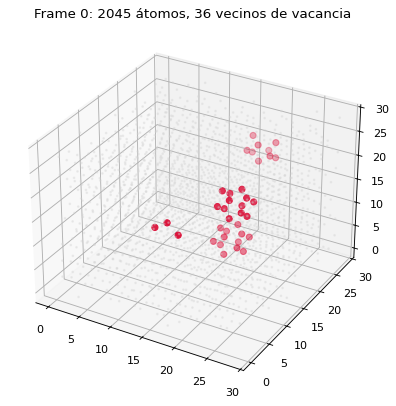

In [4]:
vv = d["vecino_vac"][a:b]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(*pos[~vv].T, s=2, c="lightgray", alpha=0.3)
ax.scatter(*pos[vv].T, s=30, c="crimson")
ax.set_title(f"Frame {f}: {len(pos)} átomos, {vv.sum()} vecinos de vacancia")
plt.show()

### El dataset de un vistazo

Cada configuración tiene una temperatura, una cantidad de vacancias (1 a 5) y una **forma**:

- **mono:** una sola vacancia;
- **conexa:** varias vacancias pegadas formando un cluster;
- **dispersa:** varias vacancias separadas entre sí (a más de 6 Å).

**Cómo armo los gráficos:** `d["cfg"]` dice de qué configuración viene cada frame; indexando `d["T"][cfg_f]` paso la temperatura de "por configuración" a "por frame". Para cada barra cuento con `(valores == e).sum()`: la comparación da una máscara de `True/False` y la suma cuenta los `True`.

**Lo que me importa del último panel:** casi todos los átomos tienen $\Delta v \approx 0$ y los vecinos de vacancia (rojo) son pocos y tienen $\Delta v$ claramente positivo. Uso escala logarítmica (`log=True`) porque si no, la barra del bulk tapa todo.

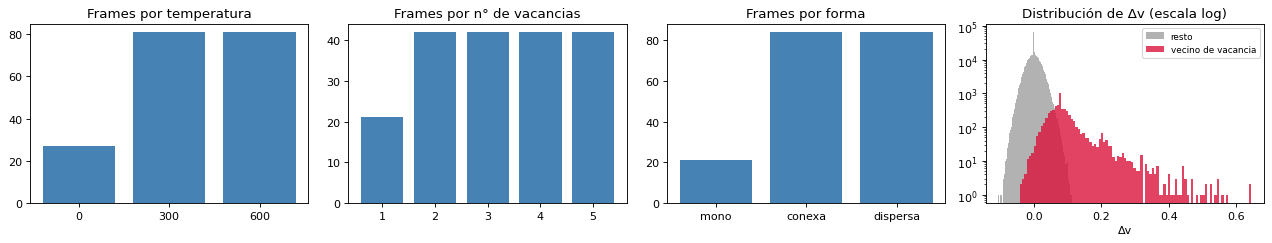

In [5]:
FORMAS = meta["formas"]                     # ["mono", "conexa", "dispersa"]
cfg_f = d["cfg"]                            # configuración de cada frame
T_f, forma_f = d["T"][cfg_f], d["forma"][cfg_f]

fig, axs = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (titulo, valores, etiquetas) in zip(axs, [
    ("Frames por temperatura", T_f, [0, 300, 600]),
    ("Frames por n° de vacancias", d["n_vac_ws"], [1, 2, 3, 4, 5]),
    ("Frames por forma", forma_f, [0, 1, 2]),
]):
    cuentas = [(valores == e).sum() for e in etiquetas]
    ax.bar([str(FORMAS[e]) if titulo.endswith("forma") else str(e) for e in etiquetas], cuentas, color="steelblue")
    ax.set_title(titulo)

vv_all = d["vecino_vac"]
axs[3].hist(d["dv"][~vv_all], bins=100, alpha=0.6, color="gray", label="resto", log=True)
axs[3].hist(d["dv"][vv_all], bins=100, alpha=0.8, color="crimson", label="vecino de vacancia", log=True)
axs[3].set_title("Distribución de Δv (escala log)"); axs[3].set_xlabel("Δv"); axs[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Distancias con condiciones periódicas

La caja es **periódica**: se repite infinitamente como un mosaico. Un átomo en $x = 0.1$ Å es vecino de uno en $x = L - 0.1$ Å, aunque en los números parezcan lejos. La distancia correcta es la de la **imagen mínima**: a cada componente del vector diferencia le resto el múltiplo de $L$ más cercano.

$$\Delta \mathbf{r} \leftarrow \Delta \mathbf{r} - L \cdot \mathrm{round}(\Delta \mathbf{r} / L)$$

**Paso a paso de `diferencias_pbc`:**

1. `pos[None, :, :]` tiene forma `[1, N, 3]` y `pos[centros][:, None, :]` tiene `[M, 1, 3]`. Al restarlos, PyTorch "estira" los ejes de tamaño 1 (**broadcasting**) y queda `[M, N, 3]`: el vector de cada centro a cada átomo, sin un solo `for`.
2. Aplico la imagen mínima.

**Comprobación:** con esto recalculo la coordinación (cuántos vecinos a menos de 3.01 Å tiene cada átomo) y la comparo con la que viene guardada en el archivo. Si da 1.0 (100 % igual), la función está bien. El `- 1` es porque cada átomo está a distancia 0 de sí mismo y se contaría.

In [6]:
def diferencias_pbc(pos, L, centros):
    """Vectores p_j - p_i con imagen mínima, para cada centro i y todo átomo j.

    pos: [N, 3], centros: [M] índices  ->  [M, N, 3]
    """
    diff = pos[None, :, :] - pos[centros][:, None, :]   # [1,N,3] - [M,1,3] -> [M,N,3]
    return diff - L * torch.round(diff / L)

# Verificación: con el corte de 3.01 Å, cada átomo de un FCC perfecto tiene 12 vecinos.
# Recalculamos la coordinación y la comparamos con la guardada en el archivo.
todos = torch.arange(len(pos))
dist = diferencias_pbc(pos, L, todos).norm(dim=-1)        # [N, N]
coord = ((dist < meta["rc_coord"]).sum(dim=1) - 1).numpy()  # -1 para no contarse a sí mismo
print("coordinación recalculada == guardada:", (coord == d["coord"][a:b]).mean())
print("átomos con coordinación < 12:", (coord < 12).sum())

coordinación recalculada == guardada: 1.0
átomos con coordinación < 12: 38


### Cómo se ve una vacancia

Quería *ver* una vacancia en los datos. Tomo frames con **una sola vacancia** a 0, 300 y 600 K.

**Paso a paso:**

1. `frame_mono(T)` busca el primer frame con forma "mono" (código 0) a esa temperatura. `np.where(condición)[0]` da los índices donde la condición es verdadera.
2. `sitio_vacancia` ubica el hueco como el **centro de sus 12 vecinos**. Ojo: si el hueco está en un borde de la caja, sus vecinos aparecen en lados opuestos y el promedio daría cualquier cosa. Por eso primero expreso todos los vecinos relativos al primero con imagen mínima, promedio, y al final `% L` lo vuelve a meter en la caja.
3. Corto una **lámina** de un plano atómico (001): me quedo con los átomos cuya z está a menos de $a_0/4$ del hueco y que están a menos de 9 Å en x e y.

**Lo que se ve:**

- A **0 K** la red está perfecta y el hueco es clarísimo: falta un punto en el patrón.
- A **300 y 600 K** la agitación térmica desordena todo. El hueco sigue ahí, pero ya no es obvio a simple vista. **Por eso no alcanza con una regla simple y tiene sentido entrenar una red.**

El color es $\Delta v$ (`cmap="coolwarm"`: azul negativo, rojo positivo). Los vecinos del hueco quedan rojos: tienen más volumen.

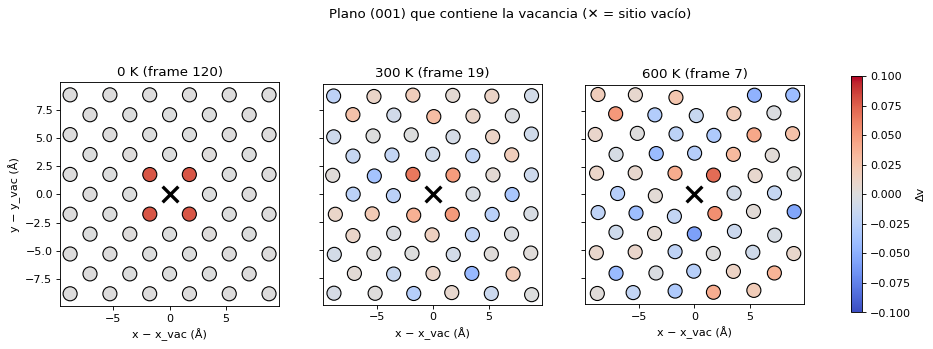

In [7]:
def frame_mono(T):
    """Primer frame con una sola vacancia a temperatura T."""
    return int(np.where((forma_f == 0) & (T_f == T))[0][0])

def sitio_vacancia(pos, L, vecinos):
    """Centro de los vecinos de la vacancia, respetando la periodicidad."""
    rel = diferencias_pbc(pos, L, vecinos[:1])[0, vecinos]   # vecinos relativos al primero
    return (pos[vecinos[0]] + rel.mean(dim=0)) % L

fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, T in zip(axs, (0, 300, 600)):
    f = frame_mono(T)
    a, b = offsets[f], offsets[f + 1]
    pos, L = frame(f)
    vac = sitio_vacancia(pos, L, torch.tensor(np.where(d["vecino_vac"][a:b])[0]))
    rel = pos - vac
    rel = rel - L * torch.round(rel / L)                         # posiciones relativas al hueco
    lamina = (rel[:, 2].abs() < meta["a0"] / 4) & (rel[:, :2].abs() < 9).all(dim=1)
    sc = ax.scatter(rel[lamina, 0], rel[lamina, 1], c=d["dv"][a:b][lamina.numpy()],
                    s=160, cmap="coolwarm", vmin=-0.1, vmax=0.1, edgecolors="k")
    ax.scatter([0], [0], marker="x", s=200, c="k", linewidths=3)
    ax.set_title(f"{T} K (frame {f})"); ax.set_aspect("equal")
    ax.set_xlabel("x − x_vac (Å)")
axs[0].set_ylabel("y − y_vac (Å)")
fig.colorbar(sc, ax=axs, label="Δv", shrink=0.8)
plt.suptitle("Plano (001) que contiene la vacancia (✕ = sitio vacío)")
plt.show()

En 3D, el hueco queda rodeado por sus 12 primeros vecinos (rojo), que forman un **cuboctaedro**. Esa "cáscara" es lo que la red tiene que aprender a reconocer. Dibujo una línea del hueco a cada vecino con `ax.plot` para que se vea la forma.

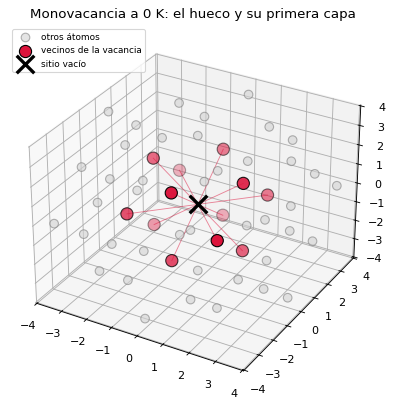

In [8]:
f = frame_mono(0)
a, b = offsets[f], offsets[f + 1]
pos, L = frame(f)
vv = d["vecino_vac"][a:b]
vac = sitio_vacancia(pos, L, torch.tensor(np.where(vv)[0]))
rel = pos - vac
rel = rel - L * torch.round(rel / L)
cerca = rel.norm(dim=1) < 5.5

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")
m = cerca & ~torch.tensor(vv)
ax.scatter(*rel[m].T, s=60, c="lightgray", edgecolors="gray", alpha=0.6, label="otros átomos")
ax.scatter(*rel[vv].T, s=120, c="crimson", edgecolors="k", label="vecinos de la vacancia")
ax.scatter([0], [0], [0], marker="x", s=250, c="k", linewidths=3, label="sitio vacío")
for p in rel[vv]:                                    # líneas del hueco a cada vecino
    ax.plot([0, p[0]], [0, p[1]], [0, p[2]], c="crimson", lw=0.8, alpha=0.5)
ax.set_title("Monovacancia a 0 K: el hueco y su primera capa"); ax.legend(loc="upper left", fontsize=8)
plt.show()

## 3. El vecindario de cada átomo: de la nube a un tensor `[k, 3]`

**Esta es la idea central del notebook.** Una CNN mira una ventana de 3×3 píxeles alrededor de cada posición. Acá la "ventana" de un átomo son sus **k vecinos más cercanos**, y lo que guardo son sus **posiciones relativas** $\mathbf{p}_j - \mathbf{p}_i$:

- **relativas** → el resultado no depende de en qué lugar de la caja está el átomo (invariancia por traslación, igual que la convolución);
- **siempre k vecinos** → todos los ejemplos tienen la misma forma `[k, 3]` y se pueden apilar en un batch.

Con $k = 18$ entran los 12 primeros vecinos FCC y 6 de la segunda capa: suficiente para "ver" si falta uno.

**Paso a paso de `vecindarios`:**

1. `diferencias_pbc` → vectores a todos los átomos `[M, N, 3]`, y `.norm(dim=-1)` → distancias `[M, N]`.
2. Pongo distancia infinita del átomo consigo mismo, para que no se elija como su propio vecino.
3. > **`topk(k, largest=False)`**: devuelve los k valores **más chicos** y sus posiciones (`.indices`). Son los índices de los k vecinos más cercanos, forma `[M, k]`.
4. > **`torch.gather(diff, 1, idx)`**: "juntar" los elementos de `diff` en las posiciones `idx` a lo largo del eje 1. Es como `diff[m, idx[m, j]]` para cada m y j, pero sin loops. El `idx[..., None].expand(-1, -1, 3)` repite cada índice 3 veces, una por cada coordenada x, y, z.

Resultado: `[M, k, 3]`.

In [9]:
K = 18

def vecindarios(pos, L, centros, k=K):
    """Posiciones relativas de los k vecinos más cercanos de cada centro: [M, k, 3]."""
    diff = diferencias_pbc(pos, L, centros)                    # [M, N, 3]
    dist = diff.norm(dim=-1)                                   # [M, N]
    dist[torch.arange(len(centros)), centros] = float("inf")  # excluir al propio átomo
    idx = dist.topk(k, largest=False).indices                  # [M, k]
    return torch.gather(diff, 1, idx[..., None].expand(-1, -1, 3))

ejemplo = vecindarios(pos, L, torch.tensor([0, int(np.where(vv)[0][0])]))
print("forma:", tuple(ejemplo.shape))
print("distancias al átomo normal     :", ejemplo[0].norm(dim=-1).numpy().round(2))
print("distancias al vecino de vacancia:", ejemplo[1].norm(dim=-1).numpy().round(2))

forma: (2, 18, 3)
distancias al átomo normal     : [2.49 2.49 2.49 2.49 2.49 2.49 2.49 2.49 2.49 2.49 2.49 2.49 3.52 3.52
 3.52 3.52 3.52 3.52]
distancias al vecino de vacancia: [2.47 2.47 2.47 2.47 2.49 2.49 2.49 2.49 2.49 2.5  2.5  3.5  3.5  3.52
 3.52 3.53 3.53 4.29]


**La diferencia que hay que ver:** el átomo normal tiene 12 vecinos a ~2.5 Å y después salta a ~3.5 Å (segunda capa). El vecino de una vacancia tiene **solo 11** a ~2.5 Å: le falta uno.

Así se ven esos dos ejemplos **tal como los recibe la red**: 18 puntos en 3D centrados en el átomo. No hay grilla, no hay orden, no hay nada más. En el gráfico de la derecha ordeno las distancias (`.sort().values`) y se ve dónde está el salto.

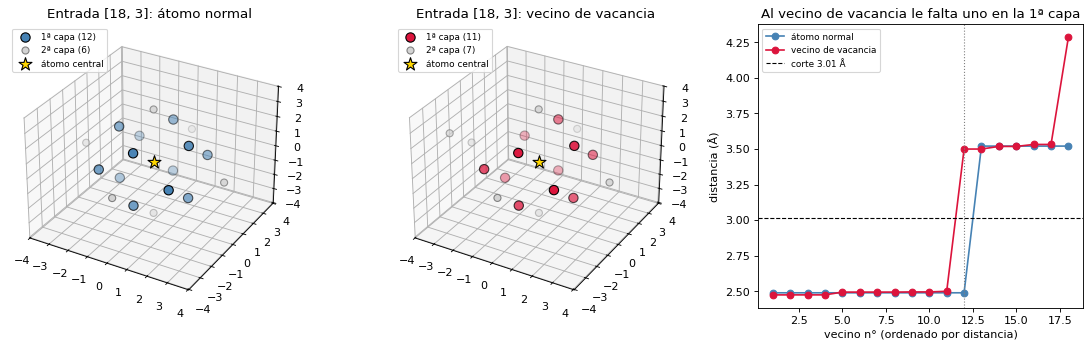

In [10]:
fig = plt.figure(figsize=(14, 4.5))
titulos = ["átomo normal", "vecino de vacancia"]
colores = ["steelblue", "crimson"]
for i in range(2):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    x = ejemplo[i]
    primera = x.norm(dim=1) < meta["rc_coord"]
    ax.scatter(*x[primera].T, s=70, c=colores[i], edgecolors="k", label=f"1ª capa ({primera.sum().item()})")
    ax.scatter(*x[~primera].T, s=40, c="lightgray", edgecolors="gray", label=f"2ª capa ({(~primera).sum().item()})")
    ax.scatter([0], [0], [0], s=150, c="gold", edgecolors="k", marker="*", label="átomo central")
    ax.set_title(f"Entrada [18, 3]: {titulos[i]}"); ax.legend(fontsize=8, loc="upper left")

ax = fig.add_subplot(1, 3, 3)
for i in range(2):
    dist = ejemplo[i].norm(dim=1).sort().values
    ax.plot(range(1, K + 1), dist, "o-", c=colores[i], label=titulos[i])
ax.axhline(meta["rc_coord"], c="k", ls="--", lw=1, label="corte 3.01 Å")
ax.axvline(12, c="gray", ls=":", lw=1)
ax.set_xlabel("vecino n° (ordenado por distancia)"); ax.set_ylabel("distancia (Å)")
ax.set_title("Al vecino de vacancia le falta uno en la 1ª capa"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Armar el dataset

**Qué hago para cada frame:**

1. Tomo **todos** los vecinos de vacancia (son ~1.5 % de los átomos) y **200 átomos normales al azar** (`np.random.choice(..., replace=False)` = sin repetir). Si usara todos los átomos, la red vería casi solo átomos normales y aprendería a decir siempre $\Delta v \approx 0$.
2. Calculo el vecindario `[k, 3]` de cada uno.
3. Guardo en listas: el vecindario (X), el Δv (Y), la coordinación (C, solo para la línea de base) y la configuración de origen (CFG).

Al final, `torch.cat` y `np.concatenate` pegan las listas en un solo tensor o arreglo.

**El split es por configuración, no por frame.** Frames de una misma simulación a distintos tiempos son casi iguales. Si uno cae en train y otro en test, el test deja de medir generalización: es **fuga de información (leakage)**. El archivo ya trae la columna `split` por configuración (0 = train, 1 = val, 2 = test), y con `d["split"][CFG]` se la paso a cada ejemplo.

In [11]:
X, Y, C, CFG = [], [], [], []
t0 = time.time()
for f in range(n_frames):
    a, b = offsets[f], offsets[f + 1]
    pos, L = frame(f)
    vv = d["vecino_vac"][a:b]
    normales = np.random.choice(np.where(~vv)[0], 200, replace=False)
    centros = np.concatenate([np.where(vv)[0], normales])

    X.append(vecindarios(pos, L, torch.tensor(centros)))
    Y.append(d["dv"][a:b][centros])
    C.append(d["coord"][a:b][centros])
    CFG.append(np.full(len(centros), d["cfg"][f]))

X = torch.cat(X)
Y = torch.tensor(np.concatenate(Y))
C = np.concatenate(C)
split = d["split"][np.concatenate(CFG)]
print(f"X {tuple(X.shape)}  Y {tuple(Y.shape)}  ({time.time() - t0:.1f} s)")
print("ejemplos train/val/test:", np.bincount(split))

X (43751, 18, 3)  Y (43751,)  (6.1 s)
ejemplos train/val/test: [14582 14585 14584]


**Normalización.** Es lo mismo que hacía `ToTensor()` con las imágenes (llevar los píxeles de 0–255 a 0–1): que los números de entrada sean de orden 1.

- Las posiciones relativas las divido por 3 Å.
- A $\Delta v$ le resto la media y lo divido por el desvío (estandarizar), usando **solo los datos de train**. Si usara val o test, se filtraría información.

**Paso a paso:** `tr, va, te` son máscaras booleanas (una por cada parte del split). `TensorDataset(X[tr], Yn[tr])` junta entradas y salidas de train, y el `DataLoader` las sirve en batches de 128 mezclados (`shuffle=True`). Con `next(iter(dl_train))` saco un batch para ver las formas.

In [12]:
tr, va, te = (torch.tensor(split == s) for s in (0, 1, 2))

X = X / 3.0
y_media, y_std = Y[tr].mean(), Y[tr].std()
Yn = (Y - y_media) / y_std

dl_train = DataLoader(TensorDataset(X[tr], Yn[tr]), batch_size=128, shuffle=True)
xb, yb = next(iter(dl_train))
print("un batch:", tuple(xb.shape), tuple(yb.shape))

un batch: (128, 18, 3) (128,)


## 5. El modelo: un mini-PointNet

Un vecindario es un **conjunto**: los 18 vecinos no tienen orden. Si usara `Flatten` + `Linear` como la CNN de la Sección 12, la salida cambiaría al reordenarlos, y eso no tiene sentido físico. La solución (PointNet, Deep Sets) tiene dos partes:

$$f(\{\mathbf{x}_1, \dots, \mathbf{x}_k\}) = \rho\Big(\max_j \; \phi(\mathbf{x}_j)\Big)$$

| Pieza | Qué hace | Equivalente en la CNN |
|---|---|---|
| $\phi$: MLP **compartido** | se aplica igual a cada vecino | el filtro de la convolución (pesos compartidos) |
| `max` sobre vecinos | resume el conjunto; no depende del orden | `MaxPool` / pooling global |
| $\rho$: MLP final | lleva el resumen a la predicción | las capas `Linear` del final |

**Lo que más me costó entender:** `nn.Linear` aplicado a un tensor `[B, k, 3]` actúa **solo sobre la última dimensión**, o sea, sobre cada vecino por separado y con los mismos pesos. No hay que hacer nada especial para "compartir pesos": sale solo.

**Paso a paso del `forward`:**

1. `self.phi(x)`: `[B, k, 3]` → `[B, k, 128]`, un vector de 128 rasgos por vecino.
2. `.max(dim=1).values`: para cada rasgo me quedo con el máximo entre los k vecinos → `[B, 128]`. (`.max` devuelve valores e índices; solo quiero los valores.)
3. `self.rho(g)`: `[B, 128]` → `[B, 1]`, y `.squeeze(-1)` saca el último eje → `[B]`.

In [13]:
class MiniPointNet(nn.Module):
    def __init__(self, ancho=128):
        super().__init__()
        self.phi = nn.Sequential(          # por vecino: [B, k, 3] -> [B, k, ancho]
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, ancho), nn.ReLU(),
        )
        self.rho = nn.Sequential(          # por conjunto: [B, ancho] -> [B, 1]
            nn.Linear(ancho, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        h = self.phi(x)                    # [B, k, ancho]
        g = h.max(dim=1).values            # [B, ancho]  <- agregación simétrica
        return self.rho(g).squeeze(-1)     # [B]

modelo = MiniPointNet().to(device)
print(modelo)
print("parámetros:", sum(p.numel() for p in modelo.parameters()))

MiniPointNet(
  (phi): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
  )
  (rho): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)
parámetros: 16897


**Comprobación de que el orden no importa:** `torch.randperm(K)` es una permutación al azar de 0..17. `x[:, perm]` reordena los vecinos de cada ejemplo. Las dos salidas tienen que ser idénticas.

In [14]:
x = X[:4].to(device)
perm = torch.randperm(K)
with torch.no_grad():
    print("salida original :", modelo(x).cpu().numpy().round(5))
    print("vecinos permutados:", modelo(x[:, perm]).cpu().numpy().round(5))

salida original : [-0.06885 -0.07059 -0.07337 -0.08086]
vecinos permutados: [-0.06885 -0.07059 -0.07337 -0.08086]


## 6. Aumento de datos: las 48 simetrías del cubo

En la Sección 15 se rotaban y espejaban imágenes para que la red aprendiera que un gato girado sigue siendo un gato. Acá es lo mismo: un cristal cúbico alineado con los ejes se ve igual si **permuto los ejes** (3! = 6 formas: xyz, yxz, zyx, ...) o **les cambio el signo** (2³ = 8 formas). 6 × 8 = **48 operaciones**: es el grupo $O_h$. Un vecindario transformado así es físicamente válido y tiene el mismo $\Delta v$.

**Paso a paso de `simetria_cubica`:**

- `torch.randperm(3)` da un orden al azar de los ejes, y `x[..., ejes]` reordena la última dimensión (x, y, z). El `...` significa "todas las dimensiones anteriores".
- `torch.randint(0, 2, (3,)) * 2 - 1` da tres valores al azar entre −1 y +1, y multiplicando invierto los ejes que tocan.

Para comprobarlo, sorteo 5000 veces y cuento cuántas combinaciones distintas salen (uso un `set`, que no guarda repetidos): tienen que ser 48.

In [15]:
def simetria_cubica(x):
    """Aplica una de las 48 operaciones de Oh, elegida al azar, a todo el batch [B, k, 3]."""
    ejes = torch.randperm(3)
    signos = torch.randint(0, 2, (3,), device=x.device) * 2 - 1
    return x[..., ejes] * signos

ops = {(tuple(torch.randperm(3).tolist()), tuple((torch.randint(0, 2, (3,)) * 2 - 1).tolist())) for _ in range(5000)}
print("operaciones distintas encontradas:", len(ops))

operaciones distintas encontradas: 48


## 7. Entrenamiento

Es el mismo bucle de la Sección 7. Me lo anoto para tenerlo siempre a mano:

| Paso | Código | Qué hace |
|---|---|---|
| 1 | `pred = modelo(xb)` | **forward**: la red predice |
| 2 | `loss = perdida(pred, yb)` | calcula cuánto se equivocó |
| 3 | `optim.zero_grad()` | borra los gradientes del batch anterior (PyTorch los **acumula**) |
| 4 | `loss.backward()` | **retropropagación**: calcula el gradiente de la pérdida respecto de cada peso |
| 5 | `optim.step()` | actualiza los pesos un pasito en la dirección que baja la pérdida |

**Otras piezas:**

> **`torch.optim.Adam`**: el optimizador. Ajusta el tamaño del paso para cada peso según la historia de sus gradientes. `lr=1e-3` es el learning rate.
>
> **`nn.MSELoss()`**: error cuadrático medio, la pérdida estándar para regresión.
>
> **`modelo.train()` / `modelo.eval()`**: cambian el modo de la red. Acá no hay dropout ni batchnorm, así que no cambia nada, pero es buena costumbre ponerlos.
>
> **`torch.no_grad()`**: en evaluación no hacen falta gradientes; así ahorra memoria y tiempo.
>
> **`torch.save(modelo.state_dict(), ...)`**: guarda los pesos. Lo hago cada vez que mejora la validación (*early stopping*): al final cargo los de la mejor época, no los de la última.

En cada batch aplico `simetria_cubica`: la red ve una versión rotada o espejada distinta cada vez.

In [16]:
def evaluar(modelo, x, y):
    modelo.eval()
    with torch.no_grad():
        pred = modelo(x.to(device)).cpu()
    return nn.functional.mse_loss(pred, y).item(), pred

modelo = MiniPointNet().to(device)
optim = torch.optim.Adam(modelo.parameters(), lr=1e-3)
perdida = nn.MSELoss()

EPOCAS = 15
hist = {"train": [], "val": []}
mejor = float("inf")
t0 = time.time()
for ep in range(EPOCAS):
    modelo.train()
    suma = 0.0
    for xb, yb in dl_train:
        xb, yb = simetria_cubica(xb.to(device)), yb.to(device)
        pred = modelo(xb)             # 1. forward
        loss = perdida(pred, yb)      # 2. pérdida
        optim.zero_grad()             # 3. limpiar gradientes viejos
        loss.backward()               # 4. retropropagación
        optim.step()                  # 5. actualizar pesos
        suma += loss.item() * len(xb)

    hist["train"].append(suma / tr.sum().item())
    hist["val"].append(evaluar(modelo, X[va], Yn[va])[0])
    if hist["val"][-1] < mejor:
        mejor = hist["val"][-1]
        torch.save(modelo.state_dict(), "mejor_modelo.pt")
    print(f"época {ep:2d} | train {hist['train'][-1]:.3f} | val {hist['val'][-1]:.3f} | {time.time() - t0:.0f} s")

época  0 | train 0.930 | val 0.772 | 0 s
época  1 | train 0.515 | val 0.367 | 1 s
época  2 | train 0.363 | val 0.350 | 1 s
época  3 | train 0.337 | val 0.343 | 1 s
época  4 | train 0.327 | val 0.292 | 1 s
época  5 | train 0.309 | val 0.287 | 1 s
época  6 | train 0.303 | val 0.261 | 2 s
época  7 | train 0.293 | val 0.256 | 2 s
época  8 | train 0.274 | val 0.253 | 2 s
época  9 | train 0.267 | val 0.231 | 2 s
época 10 | train 0.257 | val 0.223 | 2 s
época 11 | train 0.264 | val 0.220 | 3 s
época 12 | train 0.237 | val 0.213 | 3 s
época 13 | train 0.244 | val 0.201 | 3 s
época 14 | train 0.228 | val 0.202 | 3 s


**Curvas de entrenamiento.** Si la de validación empezara a subir mientras la de train sigue bajando, sería sobreajuste. Que val quede por debajo de train es normal acá: train se mide con aumento de datos y en el promedio de la época, mientras que val se mide al final de la época y sin aumento.

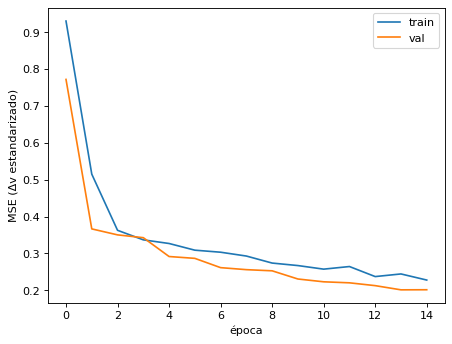

In [17]:
plt.plot(hist["train"], label="train")
plt.plot(hist["val"], label="val")
plt.xlabel("época"); plt.ylabel("MSE (Δv estandarizado)"); plt.legend(); plt.show()

## 8. Evaluación en test

Un modelo solo vale si le gana a algo más simple. Uso dos líneas de base:

- **la media:** predecir siempre el $\Delta v$ medio de train (R² = 0 por definición);
- **tabla por coordinación:** predecir el $\Delta v$ medio de train para cada número de vecinos (11, 12, ...). Es la regla "a menos vecinos, más volumen".

**Métricas, para recordar:**

- **MAE** (error absoluto medio): el promedio de |predicho − real|. En las mismas unidades que $\Delta v$.
- **R²**: qué fracción de la variación de los datos explica el modelo. 1 = perfecto, 0 = igual que predecir la media, negativo = peor que la media.

Antes de medir, cargo los pesos de la mejor época (`load_state_dict`) y **deshago la estandarización** (`pred_n * y_std + y_media`) para volver a las unidades originales.

In [18]:
modelo.load_state_dict(torch.load("mejor_modelo.pt"))
_, pred_n = evaluar(modelo, X[te], Yn[te])
pred = pred_n * y_std + y_media
real = Y[te]

tabla = {c: Y[tr][C[tr.numpy()] == c].mean() for c in np.unique(C[tr.numpy()])}
pred_coord = torch.tensor([tabla.get(c, y_media).item() for c in C[te.numpy()]])

def metricas(p):
    mae = (p - real).abs().mean().item()
    r2 = 1 - ((p - real) ** 2).sum().item() / ((real - real.mean()) ** 2).sum().item()
    return f"MAE {mae:.4f} | R² {r2:6.3f}"

print("media              :", metricas(torch.full_like(real, y_media.item())))
print("tabla coordinación :", metricas(pred_coord))
print("mini-PointNet      :", metricas(pred))

media              : MAE 0.0269 | R² -0.000
tabla coordinación : MAE 0.0158 | R²  0.733
mini-PointNet      : MAE 0.0113 | R²  0.787


**Gráfico de paridad:** predicho contra real, coloreado por temperatura. Si fuera perfecto, todo caería sobre la diagonal punteada. Me fijo en dónde se abre la nube de puntos.

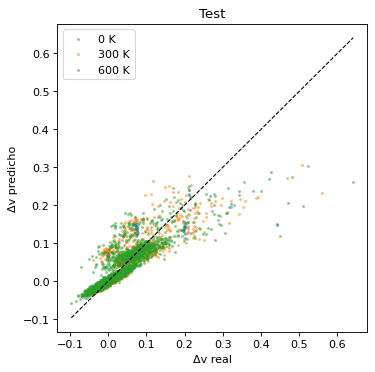

In [19]:
T_te = d["T"][np.concatenate(CFG)][te.numpy()]
fig, ax = plt.subplots(figsize=(5, 5))
for T in (0, 300, 600):
    m = T_te == T
    ax.scatter(real[m], pred[m], s=3, alpha=0.4, label=f"{T} K")
lim = [real.min(), real.max()]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("Δv real"); ax.set_ylabel("Δv predicho"); ax.legend(); ax.set_title("Test")
plt.show()

## Lo que me llevo de este notebook

| Paso | Código clave | Idea |
|---|---|---|
| Formato | `pos[offsets[f]:offsets[f+1]]` | nubes de tamaño variable concatenadas |
| Periodicidad | `diff - L * round(diff / L)` | imagen mínima |
| Vecindario | `topk` + `gather` → `[M, k, 3]` | la "ventana del kernel" de un átomo |
| Split | `split` por configuración | evitar fuga de información entre frames |
| Modelo | `phi(x).max(dim=1)` | MLP compartido + agregación simétrica |
| Aumento | permutar ejes × cambiar signos | 48 simetrías de $O_h$ |
| Entrenamiento | forward, loss, zero_grad, backward, step | igual que en el curso |

**Cómo se conecta con la tesis:** PointNeXt y Point Transformer V3 (ver el README del repo) son versiones más grandes de lo mismo. Apilan varias capas como esta, submuestrean la nube entre capas (FPS o grid pooling) y, en PTv3, reemplazan el `max` por atención.

## Para probar

1. Cambiar `K` a 12 y a 30. ¿Cuál anda mejor y por qué?
2. Reemplazar `max` por `mean` en `forward`. ¿Sigue siendo invariante por permutación? ¿Cambia el resultado?
3. Entrenar sin `simetria_cubica`. ¿Qué pasa con la brecha entre train y val?
4. Separar las métricas de test por temperatura. ¿Dónde falla más el modelo?
5. Usar el $\Delta v$ predicho para clasificar "vecino de vacancia sí/no" con un umbral. ¿Qué precisión logra?